<a href="https://colab.research.google.com/github/Varshini151205/DL/blob/main/DL7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Implementation of LeNet**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


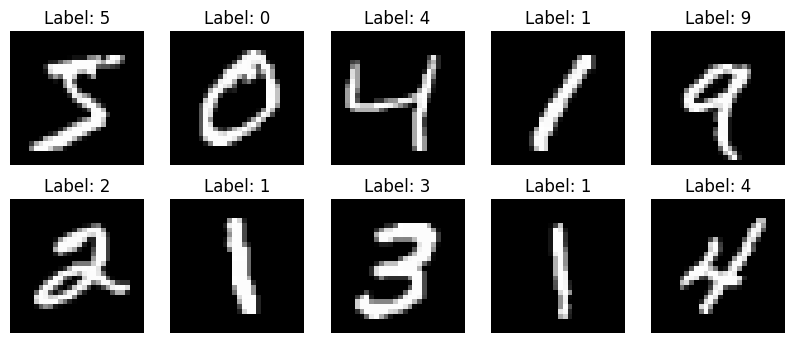

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.8832 - loss: 0.3973 - val_accuracy: 0.9523 - val_loss: 0.1714
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9563 - loss: 0.1458 - val_accuracy: 0.9695 - val_loss: 0.1072
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9716 - loss: 0.0958 - val_accuracy: 0.9744 - val_loss: 0.0864
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9783 - loss: 0.0712 - val_accuracy: 0.9776 - val_loss: 0.0733
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9828 - loss: 0.0574 - val_accuracy: 0.9809 - val_loss: 0.0628
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9860 - loss: 0.0457 - val_accuracy: 0.9824 - val_loss: 0.0601
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9881 - loss: 0.0383 - val_accuracy: 0.9838 - val_loss: 0.0548
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9891 - loss: 0.0330 - 

In [ ]:
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Visualize The Training Data
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

#Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

#Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]

#Normalize
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

#Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


#One Hot Encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

LeNet5_Model=Sequential()

LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Flatten())

LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
LeNet5_Model.summary()
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))

test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)


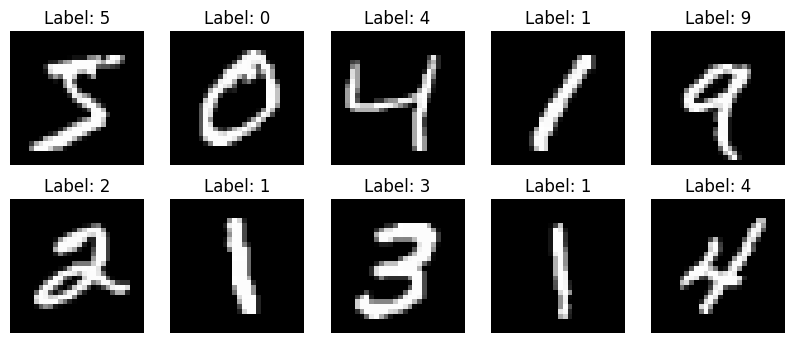

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 7, 7, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        94,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,786 (421.04 KB)

 Trainable params: 107,786 (421.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 89ms/step - accuracy: 0.8970 - loss: 0.3580 - val_accuracy: 0.9534 - val_loss: 0.1570
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - accuracy: 0.9593 - loss: 0.1347 - val_accuracy: 0.9690 - val_loss: 0.1024
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - accuracy: 0.9721 - loss: 0.0912 - val_accuracy: 0.9702 - val_loss: 0.0953
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.9784 - loss: 0.0703 - val_accuracy: 0.9768 - val_loss: 0.0785
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9826 - loss: 0.0557 - val_accuracy: 0.9782 - val_loss: 0.0737
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9866 - loss: 0.0447 - val_accuracy: 0.9803 - val_loss: 0.0626
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.9898 - loss: 0.0344 - val_accuracy: 0.9821 - val_loss: 0.0609
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.9918 - loss: 0.0282

In [ ]:
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Visualize The Training Data
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

#Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

#Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]

#Normalize
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

#Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


#One Hot Encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

LeNet5_Model=Sequential()

LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5),padding='same', activation='tanh', input_shape=(28, 28, 1)))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5),padding='same', activation='tanh'))
LeNet5_Model.add(AveragePooling2D((2, 2)))
LeNet5_Model.add(Flatten())

LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
LeNet5_Model.summary()
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))

test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)







when we added padding the no.of parameters are increased
computation time also got increased

In [6]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from keras import Sequential
from keras.layers import Dense,Dropout,Conv2D,MaxPooling2D,Flatten
import matplotlib.pyplot as plt
import gc
keras.backend.clear_session()
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=tf.expand_dims(x_train,axis=-1)
x_test=tf.expand_dims(x_test,axis=-1)
def process_image(image,label):
  image=tf.image.grayscale_to_rgb(image)
  image=tf.image.resize(image, (112, 112))
  return image/255.0,tf.one_hot(label,10)
train_dataset=tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset=train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset=tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset=test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

tf.keras.mixed_precision.set_global_policy('mixed_float16')

model = Sequential()
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))
model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))  #output layer
model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)
gc.collect()
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
  27/7500 ━━━━━━━━━━━━━━━━━━━━ 33:24:42 16s/step - accuracy: 0.0967 - loss: 3.8665

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from keras import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
import matplotlib.pyplot as plt
import gc
keras.backend.clear_session()
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

def process_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0   # normalize
    label = tf.one_hot(label, 10)
    return image, label
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(32).prefetch(tf.data.AUTOTUNE)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)
gc.collect()
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9365 - loss: 0.2092 - val_accuracy: 0.9844 - val_loss: 0.0492
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 47ms/step - accuracy: 0.9767 - loss: 0.0784 - val_accuracy: 0.9880 - val_loss: 0.0402
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9839 - loss: 0.0551 - val_accuracy: 0.9881 - val_loss: 0.0358
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9872 - loss: 0.0432 - val_accuracy: 0.9898 - val_loss: 0.0290
Epoch 5/5
 677/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.9883 - loss: 0.0377